# C3.1.3 - Descriptive Analysis - Education of Founders

This notebook is the third part of the descriptive analysis pipeline. It focuses on the educational backgrounds of founders strictly prior to founding their ventures, analyzing:
1. The degree levels they achieved (Bachelor, Master, PhD, MBA).
2. The fields of study they pursued (STEM, CS, Business, Econ, Humanities, etc.).
3. Transition heatmaps from their primary educational fields to founded venture industries.
4. Founder age (career experience) distribution by degree level and prior role intersections.

### Data Dictionary
Refer to [C3.1.1](file:///Users/milanmiric/Documents/Research/Active%20Papers/LinkedIn%20Entreprenurship%20&%20Experience%20%5BPaper%202%5D/Data%20Extraction%20and%20Analysis/C3%20-%20Analysis/C3.1%20-%20Descriptive%20Analysis/C3.1.1%20-%20Descriptive%20Analysis%20-%20Position%20Prior%20to%20Founding.ipynb) for variable definitions.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure styling to match academic publication standards
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 11


In [2]:
# File paths
BASE_DIR = "../.."
MATCHED_DATA_PATH = os.path.join(BASE_DIR, "D - Data/D3 - Refined Datasets for Analysis/Founder_Level_Merged_Dataset.csv")

print("Loading dataset...")
df_matched = pd.read_csv(MATCHED_DATA_PATH)
print(f"Matched Dataset: {len(df_matched):,} rows, {df_matched.shape[1]} columns.")

# Merge role classifications
print("Merging role classifications...")
class_roles_path = os.path.join(BASE_DIR, "C1 - Data Extraction/Extract General Data/Variable classification/classified_roles.csv")
df_class = pd.read_csv(class_roles_path, usecols=['role', 'category'])
df_matched = df_matched.merge(df_class, left_on='prior_role_k500_v3', right_on='role', how='left')
df_matched = df_matched.rename(columns={'category': 'prior_role_category'})
df_matched = df_matched.drop(columns=['role'])
print("Merge complete.")


Loading dataset...


Matched Dataset: 1,239,185 rows, 491 columns.
Merging role classifications...


Merge complete.


## 1. Data Filtering

We apply the same exclusion criteria as in C3.1.1 to analyze a consistent, clean sample of founders:


In [3]:
def filter_founder_data(df):
    print(f"Initial raw rows: {len(df):,}")
    # 1. Filter out missing/invalid LinkedIn company IDs
    df_filtered = df[df['venture_firm_id'].notnull() & (df['venture_firm_id'] != 0)].copy()
    print(f"After LinkedIn ID filter: {len(df_filtered):,}")
    
    # 2. Filter by YEARFOUNDED being between 2000 and 2024
    df_filtered = df_filtered[df_filtered['YEARFOUNDED'].notnull()].copy()
    df_filtered = df_filtered[(df_filtered['YEARFOUNDED'] >= 2000) & (df_filtered['YEARFOUNDED'] <= 2024)].copy()
    print(f"After founding year range filter (2000-2024): {len(df_filtered):,}")
    
    # 3. Filter out companies with more than 10 founders
    founder_counts = df_filtered.groupby('venture_firm_id')['user_id'].transform('nunique')
    df_filtered = df_filtered[founder_counts <= 10].copy()
    print(f"After co-founder limit filter (<= 10 founders): {len(df_filtered):,}")
    
    # 4. Filter out companies that last less than one year
    df_filtered = df_filtered[df_filtered['venture_duration_years'] >= 1.0].copy()
    print(f"After venture duration filter (>= 1 year): {len(df_filtered):,}")
    return df_filtered

df_matched_filtered = filter_founder_data(df_matched)


Initial raw rows: 1,239,185


After LinkedIn ID filter: 612,481


After founding year range filter (2000-2024): 57,475
After co-founder limit filter (<= 10 founders): 57,444
After venture duration filter (>= 1 year): 52,496


## Section A: Educational Fields and Degrees by Founder Subgroup

The following graphs show the distribution of educational credentials across the three founder subgroups:
- **Graph A1**: Grouped bar chart showing the share of founders with different degrees and fields of study.
- **Graph A2 (Technology Exclusion)**: Comparison with technology ventures excluded (overlaid bar plot and point plot using marker `*`).


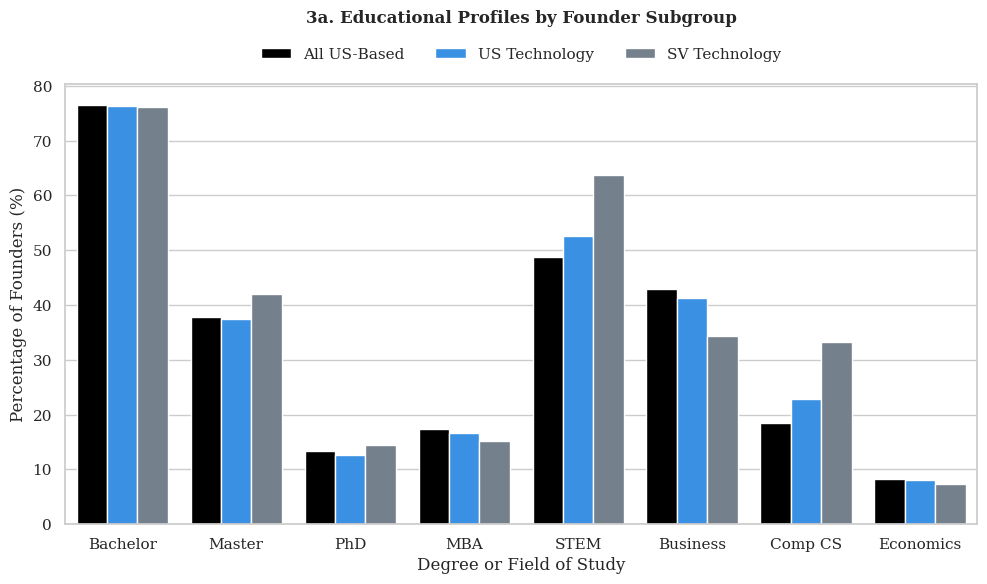

In [4]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Define technology companies & Silicon Valley
is_tech = df_matched_filtered['venture_rics_k50'].str.contains('Information Technology|IT|Software|Hardware|Internet|Digital Commerce|Technology', case=False, na=False) | \
          df_matched_filtered['venture_rics_k200'].str.contains('Information Technology|IT|Software|Hardware|Internet|Digital Commerce|Technology|Cybersecurity', case=False, na=False) | \
          df_matched_filtered['venture_rics_k400'].str.contains('Information Technology|IT|Software|Hardware|Internet|Digital Commerce|Technology|Cybersecurity', case=False, na=False)

is_sv = df_matched_filtered['venture_metro_area'].str.contains('san francisco|san jose', case=False, na=False)

# Define subgroups
df_all_us = df_matched_filtered.copy()
df_tech = df_matched_filtered[is_tech].copy()
df_sv_tech = df_matched_filtered[is_tech & is_sv].copy()
df_all_us_ex = df_matched_filtered[~is_tech].copy()

# Prepare shares data (including tech)
fields = ['has_bachelor', 'has_master', 'has_phd', 'has_mba', 'has_stem', 'has_business', 'has_cs', 'has_econ']
labels = ['Bachelor', 'Master', 'PhD', 'MBA', 'STEM', 'Business', 'Comp CS', 'Economics']

df_shares_long = pd.DataFrame()
for grp, df_grp in [('All US-Based', df_all_us), ('US Technology', df_tech), ('SV Technology', df_sv_tech)]:
    group_shares = []
    for field, label in zip(fields, labels):
        share = df_grp[field].mean() * 100
        group_shares.append({'Field': label, 'Percentage': share, 'Group': grp})
    df_shares_long = pd.concat([df_shares_long, pd.DataFrame(group_shares)], ignore_index=True)

palette = {'All US-Based': 'black', 'US Technology': 'dodgerblue', 'SV Technology': 'slategrey'}

# Plot Graph A1
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_shares_long, x='Field', y='Percentage', hue='Group', ax=ax, palette=palette)
ax.set_title("3a. Educational Profiles by Founder Subgroup", y=1.12, fontsize=12, fontweight='bold')
ax.set_xlabel("Degree or Field of Study")
ax.set_ylabel("Percentage of Founders (%)")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)
plt.tight_layout()

output_fig_dir = "/Users/milanmiric/Documents/Research/Active Papers/LinkedIn Entreprenurship & Experience [Paper 2]/Writing and Documents/Revised Paper/figures"
os.makedirs(output_fig_dir, exist_ok=True)
fig_a_path = os.path.join(output_fig_dir, "Figure_3a.png")
plt.savefig(fig_a_path, dpi=300, bbox_inches='tight')
plt.show()


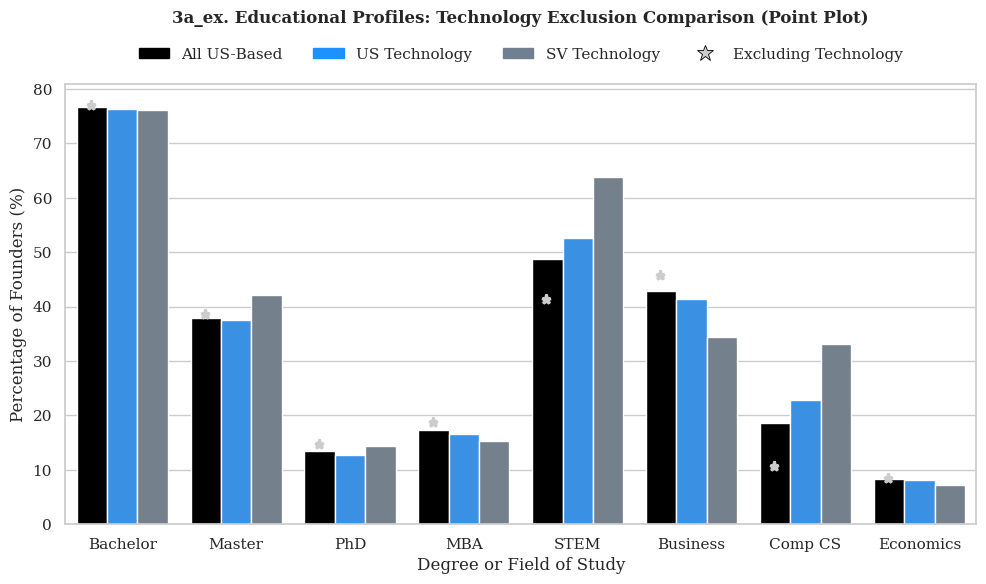

In [5]:
# Prepare shares data (excluding tech)
group_shares_ex = []
for field, label in zip(fields, labels):
    share = df_all_us_ex[field].mean() * 100
    group_shares_ex.append({'Field': label, 'Percentage': share, 'Group': 'All US-Based'})
df_shares_ex = pd.DataFrame(group_shares_ex)

# Add dummy rows to satisfy pointplot dodge check
dummy_rows = pd.DataFrame([
    {'Field': 'Bachelor', 'Percentage': np.nan, 'Group': 'US Technology'},
    {'Field': 'Bachelor', 'Percentage': np.nan, 'Group': 'SV Technology'}
])
df_shares_ex_all = pd.concat([df_shares_ex, dummy_rows], ignore_index=True)

# Plot Graph A2
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_shares_long, x='Field', y='Percentage', hue='Group', ax=ax2, palette=palette)

sns.pointplot(
    data=df_shares_ex_all,
    x='Field',
    y='Percentage',
    hue='Group',
    ax=ax2,
    palette={'All US-Based': '#cccccc', 'US Technology': '#cccccc', 'SV Technology': '#cccccc'},
    markers='*',
    linestyles='',
    dodge=0.55,
    errorbar=None
)

for collection in ax2.collections:
    collection.set_edgecolor('black')
    collection.set_linewidth(0.6)

ax2.set_title("3a_ex. Educational Profiles: Technology Exclusion Comparison (Point Plot)", y=1.12, fontsize=12, fontweight='bold')
ax2.set_xlabel("Degree or Field of Study")
ax2.set_ylabel("Percentage of Founders (%)")

p1 = mpatches.Patch(color='black', label='All US-Based')
p2 = mpatches.Patch(color='dodgerblue', label='US Technology')
p3 = mpatches.Patch(color='slategrey', label='SV Technology')
m2 = mlines.Line2D([], [], color='#cccccc', marker='*', linestyle='', markersize=12, markeredgecolor='black', markeredgewidth=0.6, label='Excluding Technology')

ax2.legend(handles=[p1, p2, p3, m2], loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
plt.tight_layout()
fig_a2_path = os.path.join(output_fig_dir, "Figure_3a_ex_software.png")
plt.savefig(fig_a2_path, dpi=300, bbox_inches='tight')
plt.show()


## Section B: Transition Heatmap from Education Field to Founded Venture Industry

We assign each founder a single primary educational background based on the hierarchy of CS, STEM, MBA, Business, Econ, Law, Medicine, and Humanities.
We map these educational backgrounds to the top 10 venture industries in a transition heatmap:
- **Graph B1**: Heatmap for all educational backgrounds (Greys colormap, Black histograms).
- **Graph B2**: Heatmap for Technical Education backgrounds (Blues colormap, Dodger Blue histograms).
- **Graph B3**: Heatmap for Business Education backgrounds (Greys colormap, Slate Grey histograms).


/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98808/236314634.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = cstab.applymap(lambda v: f"{v:.1f}%")


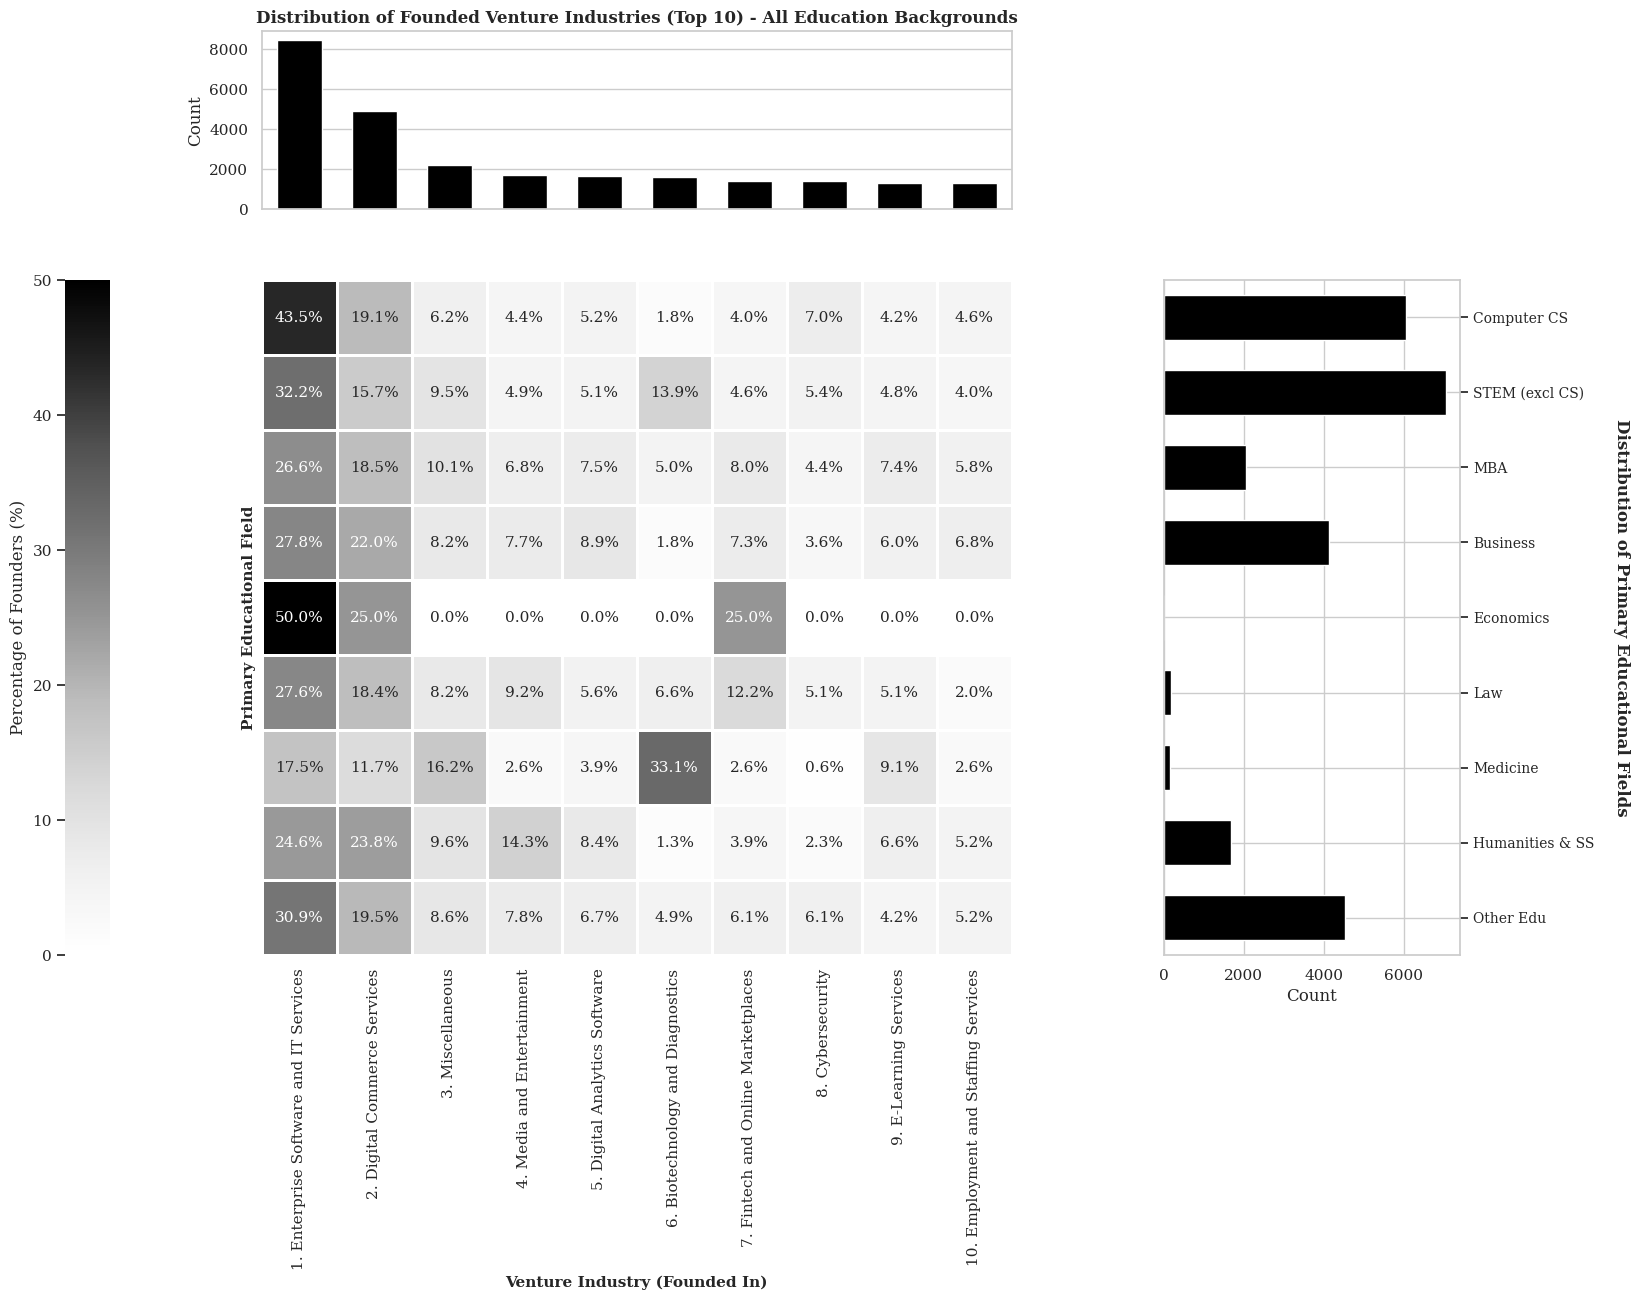

In [6]:
import matplotlib.gridspec as gridspec

# Define primary educational field hierarchically
def get_primary_edu(r):
    if r['has_cs'] == 1.0: return 'Computer CS'
    elif r['has_stem'] == 1.0: return 'STEM (excl CS)'
    elif r['has_mba'] == 1.0: return 'MBA'
    elif r['has_business'] == 1.0: return 'Business'
    elif r['has_econ'] == 1.0: return 'Economics'
    elif r['has_law'] == 1.0: return 'Law'
    elif r['has_med'] == 1.0: return 'Medicine'
    elif r['has_humanities'] == 1.0: return 'Humanities & SS'
    else: return 'Other Edu'

df_matched_filtered['primary_edu'] = df_matched_filtered.apply(get_primary_edu, axis=1)

# Top 10 venture industries
top_venture_k200 = df_matched_filtered['venture_rics_k200'].value_counts().head(10).index.tolist()

# Filter for top venture industries
df_joint = df_matched_filtered[df_matched_filtered['venture_rics_k200'].isin(top_venture_k200)].copy()

edu_order = ['Computer CS', 'STEM (excl CS)', 'MBA', 'Business', 'Economics', 'Law', 'Medicine', 'Humanities & SS', 'Other Edu']

cstab = pd.crosstab(
    df_joint['primary_edu'],
    df_joint['venture_rics_k200'],
    normalize='index'
) * 100
cstab = cstab.reindex(index=edu_order, columns=top_venture_k200, fill_value=0.0)

y_labels = edu_order
x_labels = [f"{i+1}. {name}" for i, name in enumerate(top_venture_k200)]
annot_labels = cstab.applymap(lambda v: f"{v:.1f}%")

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(4, 3, hspace=0.4, wspace=0.2, width_ratios=[0.15, 3.0, 1.0])

# Top marginal bar plot - Black
ax_top = fig.add_subplot(gs[0, 1])
venture_counts = df_joint['venture_rics_k200'].value_counts().loc[top_venture_k200]
x_positions = [i + 0.5 for i in range(len(top_venture_k200))]
ax_top.bar(x_positions, venture_counts.values, width=0.6, color="black")
ax_top.set_xlim(0, len(top_venture_k200))
ax_top.set_title("Distribution of Founded Venture Industries (Top 10) - All Education Backgrounds", fontsize=12, fontweight='bold')
ax_top.set_ylabel("Count")
ax_top.xaxis.set_visible(False)

# Colorbar axis
ax_cbar = fig.add_subplot(gs[1:4, 0])

# Main Heatmap - Greys, cell spacing, square=True
ax_main = fig.add_subplot(gs[1:4, 1])
sns.heatmap(
    cstab,
    annot=annot_labels,
    fmt="",
    cmap="Greys",
    linewidths=1.0,
    linecolor='white',
    square=True,
    xticklabels=x_labels,
    yticklabels=False,
    cbar=True,
    cbar_ax=ax_cbar,
    cbar_kws={'label': 'Percentage of Founders (%)'},
    ax=ax_main
)
ax_main.set_xlabel("Venture Industry (Founded In)", fontsize=11, fontweight='bold')
ax_main.set_ylabel("Primary Educational Field", fontsize=11, fontweight='bold')
plt.setp(ax_main.get_xticklabels(), rotation=90, ha='center')

ax_cbar.yaxis.set_ticks_position('left')
ax_cbar.yaxis.set_label_position('left')

# Right marginal bar plot - Black
ax_right = fig.add_subplot(gs[1:4, 2])
edu_counts = df_joint['primary_edu'].value_counts().reindex(edu_order, fill_value=0)
y_positions = [i + 0.5 for i in range(len(edu_order))]
ax_right.barh(y_positions, edu_counts.values, height=0.6, color="black", align='center')
ax_right.set_ylim(len(edu_order), 0)
ax_right.set_yticks(y_positions)
ax_right.set_yticklabels(y_labels, fontsize=10)
ax_right.yaxis.tick_right()
ax_right.yaxis.set_label_position("right")
ax_right.set_ylabel("Distribution of Primary Educational Fields", rotation=270, labelpad=25, fontsize=12, fontweight='bold')
ax_right.set_xlabel("Count")

# Align top and right marginal plots perfectly
fig.canvas.draw()
pos = ax_main.get_position()
pos_top = ax_top.get_position()
ax_top.set_position([pos.x0, pos_top.y0, pos.width, pos_top.height])
pos_right = ax_right.get_position()
ax_right.set_position([pos_right.x0, pos.y0, pos_right.width, pos.height])

fig_b_path = os.path.join(output_fig_dir, "Figure_3b.png")
plt.savefig(fig_b_path, dpi=300, bbox_inches='tight')
plt.show()


/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98808/790197823.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels_tech = cstab_tech.applymap(lambda v: f"{v:.1f}%")


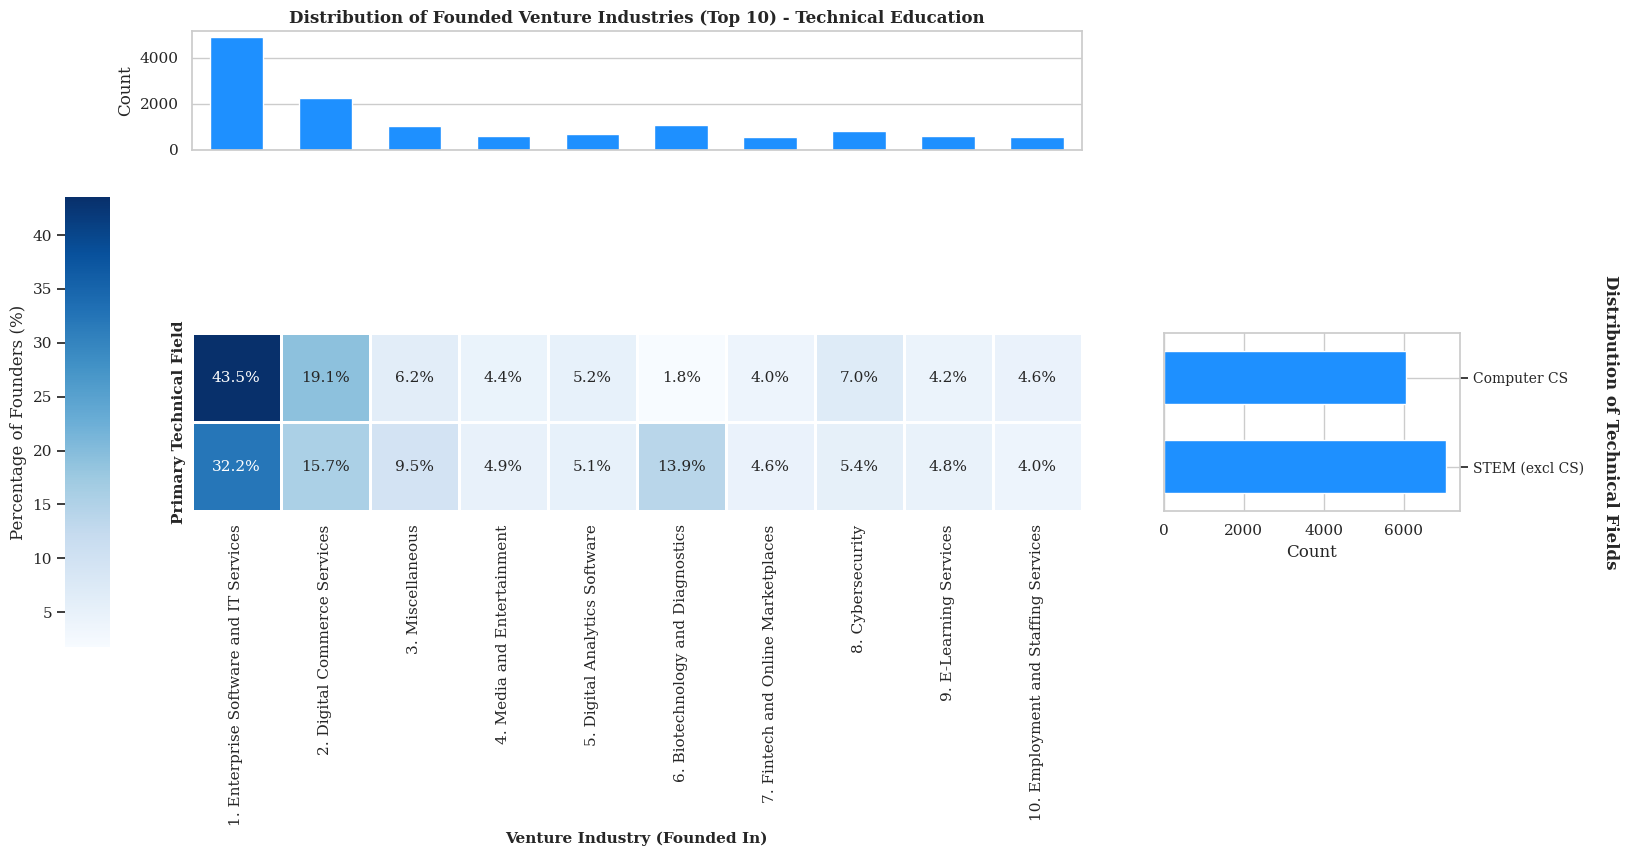

In [7]:
# Filter for Technical Education only (STEM or CS)
df_joint_tech = df_joint[(df_joint['has_stem'] == 1.0) | (df_joint['has_cs'] == 1.0)].copy()
cstab_tech = pd.crosstab(
    df_joint_tech['primary_edu'],
    df_joint_tech['venture_rics_k200'],
    normalize='index'
) * 100
tech_edu_order = ['Computer CS', 'STEM (excl CS)']
cstab_tech = cstab_tech.reindex(index=tech_edu_order, columns=top_venture_k200, fill_value=0.0)
annot_labels_tech = cstab_tech.applymap(lambda v: f"{v:.1f}%")

fig_tech = plt.figure(figsize=(18, 8))
gs_tech = gridspec.GridSpec(4, 3, hspace=0.4, wspace=0.2, width_ratios=[0.15, 3.0, 1.0])

# Top marginal - Dodger Blue
ax_top_tech = fig_tech.add_subplot(gs_tech[0, 1])
venture_counts_tech = df_joint_tech['venture_rics_k200'].value_counts().reindex(top_venture_k200, fill_value=0)
ax_top_tech.bar(x_positions, venture_counts_tech.values, width=0.6, color="dodgerblue")
ax_top_tech.set_xlim(0, len(top_venture_k200))
ax_top_tech.set_title("Distribution of Founded Venture Industries (Top 10) - Technical Education", fontsize=12, fontweight='bold')
ax_top_tech.set_ylabel("Count")
ax_top_tech.xaxis.set_visible(False)

# Colorbar
ax_cbar_tech = fig_tech.add_subplot(gs_tech[1:4, 0])

# Main Heatmap - Blues, cell spacing, square=True
ax_main_tech = fig_tech.add_subplot(gs_tech[1:4, 1])
sns.heatmap(
    cstab_tech,
    annot=annot_labels_tech,
    fmt="",
    cmap="Blues",
    linewidths=1.0,
    linecolor='white',
    square=True,
    xticklabels=x_labels,
    yticklabels=False,
    cbar=True,
    cbar_ax=ax_cbar_tech,
    cbar_kws={'label': 'Percentage of Founders (%)'},
    ax=ax_main_tech
)
ax_main_tech.set_xlabel("Venture Industry (Founded In)", fontsize=11, fontweight='bold')
ax_main_tech.set_ylabel("Primary Technical Field", fontsize=11, fontweight='bold')
plt.setp(ax_main_tech.get_xticklabels(), rotation=90, ha='center')

ax_cbar_tech.yaxis.set_ticks_position('left')
ax_cbar_tech.yaxis.set_label_position('left')

# Right marginal - Dodger Blue
ax_right_tech = fig_tech.add_subplot(gs_tech[1:4, 2])
edu_counts_tech = df_joint_tech['primary_edu'].value_counts().reindex(tech_edu_order, fill_value=0)
y_positions_tech = [i + 0.5 for i in range(len(tech_edu_order))]
ax_right_tech.barh(y_positions_tech, edu_counts_tech.values, height=0.6, color="dodgerblue", align='center')
ax_right_tech.set_ylim(len(tech_edu_order), 0)
ax_right_tech.set_yticks(y_positions_tech)
ax_right_tech.set_yticklabels(tech_edu_order, fontsize=10)
ax_right_tech.yaxis.tick_right()
ax_right_tech.yaxis.set_label_position("right")
ax_right_tech.set_ylabel("Distribution of Technical Fields", rotation=270, labelpad=25, fontsize=12, fontweight='bold')
ax_right_tech.set_xlabel("Count")

# Perfect alignment
fig_tech.canvas.draw()
pos_t = ax_main_tech.get_position()
pos_top_t = ax_top_tech.get_position()
ax_top_tech.set_position([pos_t.x0, pos_top_t.y0, pos_t.width, pos_top_t.height])
pos_right_t = ax_right_tech.get_position()
ax_right_tech.set_position([pos_right_t.x0, pos_t.y0, pos_right_t.width, pos_t.height])

fig_b_tech_path = os.path.join(output_fig_dir, "Figure_3b_technical.png")
plt.savefig(fig_b_tech_path, dpi=300, bbox_inches='tight')
plt.show()


/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98808/867802661.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels_bus = cstab_bus.applymap(lambda v: f"{v:.1f}%")


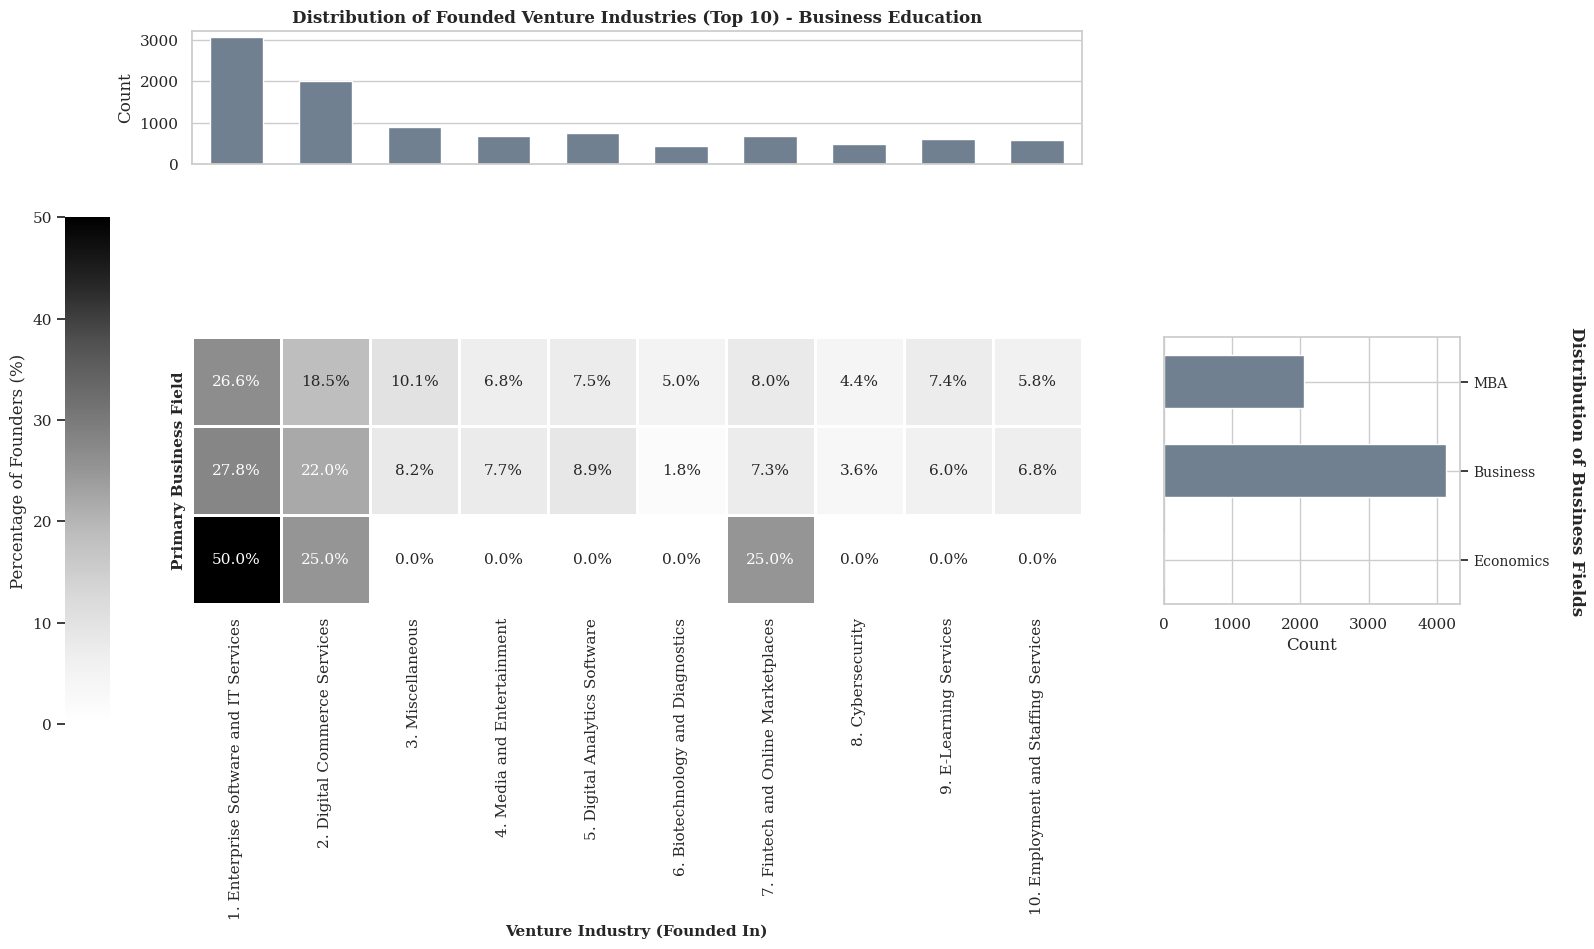

In [8]:
# Filter for Business Education only (Business, Econ, or MBA)
df_joint_bus = df_joint[(df_joint['has_business'] == 1.0) | (df_joint['has_mba'] == 1.0) | (df_joint['has_econ'] == 1.0)].copy()
cstab_bus = pd.crosstab(
    df_joint_bus['primary_edu'],
    df_joint_bus['venture_rics_k200'],
    normalize='index'
) * 100
bus_edu_order = ['MBA', 'Business', 'Economics']
cstab_bus = cstab_bus.reindex(index=bus_edu_order, columns=top_venture_k200, fill_value=0.0)
annot_labels_bus = cstab_bus.applymap(lambda v: f"{v:.1f}%")

fig_bus = plt.figure(figsize=(18, 9))
gs_bus = gridspec.GridSpec(4, 3, hspace=0.4, wspace=0.2, width_ratios=[0.15, 3.0, 1.0])

# Top marginal - Slate Grey
ax_top_bus = fig_bus.add_subplot(gs_bus[0, 1])
venture_counts_bus = df_joint_bus['venture_rics_k200'].value_counts().reindex(top_venture_k200, fill_value=0)
ax_top_bus.bar(x_positions, venture_counts_bus.values, width=0.6, color="slategrey")
ax_top_bus.set_xlim(0, len(top_venture_k200))
ax_top_bus.set_title("Distribution of Founded Venture Industries (Top 10) - Business Education", fontsize=12, fontweight='bold')
ax_top_bus.set_ylabel("Count")
ax_top_bus.xaxis.set_visible(False)

# Colorbar
ax_cbar_bus = fig_bus.add_subplot(gs_bus[1:4, 0])

# Main Heatmap - Greys, cell spacing, square=True
ax_main_bus = fig_bus.add_subplot(gs_bus[1:4, 1])
sns.heatmap(
    cstab_bus,
    annot=annot_labels_bus,
    fmt="",
    cmap="Greys",
    linewidths=1.0,
    linecolor='white',
    square=True,
    xticklabels=x_labels,
    yticklabels=False,
    cbar=True,
    cbar_ax=ax_cbar_bus,
    cbar_kws={'label': 'Percentage of Founders (%)'},
    ax=ax_main_bus
)
ax_main_bus.set_xlabel("Venture Industry (Founded In)", fontsize=11, fontweight='bold')
ax_main_bus.set_ylabel("Primary Business Field", fontsize=11, fontweight='bold')
plt.setp(ax_main_bus.get_xticklabels(), rotation=90, ha='center')

ax_cbar_bus.yaxis.set_ticks_position('left')
ax_cbar_bus.yaxis.set_label_position('left')

# Right marginal - Slate Grey
ax_right_bus = fig_bus.add_subplot(gs_bus[1:4, 2])
edu_counts_bus = df_joint_bus['primary_edu'].value_counts().reindex(bus_edu_order, fill_value=0)
y_positions_bus = [i + 0.5 for i in range(len(bus_edu_order))]
ax_right_bus.barh(y_positions_bus, edu_counts_bus.values, height=0.6, color="slategrey", align='center')
ax_right_bus.set_ylim(len(bus_edu_order), 0)
ax_right_bus.set_yticks(y_positions_bus)
ax_right_bus.set_yticklabels(bus_edu_order, fontsize=10)
ax_right_bus.yaxis.tick_right()
ax_right_bus.yaxis.set_label_position("right")
ax_right_bus.set_ylabel("Distribution of Business Fields", rotation=270, labelpad=25, fontsize=12, fontweight='bold')
ax_right_bus.set_xlabel("Count")

# Perfect alignment
fig_bus.canvas.draw()
pos_b = ax_main_bus.get_position()
pos_top_b = ax_top_bus.get_position()
ax_top_bus.set_position([pos_b.x0, pos_top_b.y0, pos_b.width, pos_top_b.height])
pos_right_b = ax_right_bus.get_position()
ax_right_bus.set_position([pos_right_b.x0, pos_b.y0, pos_right_b.width, pos_b.height])

fig_b_bus_path = os.path.join(output_fig_dir, "Figure_3b_business.png")
plt.savefig(fig_b_bus_path, dpi=300, bbox_inches='tight')
plt.show()


## Section C: Founder Age (Years Since First Position) by Degree Level

We plot the Kernel Density Estimate (KDE) distribution for the years since the founder's first position (`years_since_first_job`) across different degree levels:
- **PhD / Doctorate** (color coded in **slategrey**)
- **Master / MBA** (color coded in **dodgerblue**)
- **Bachelor / Undergraduate** (color coded in **black**)


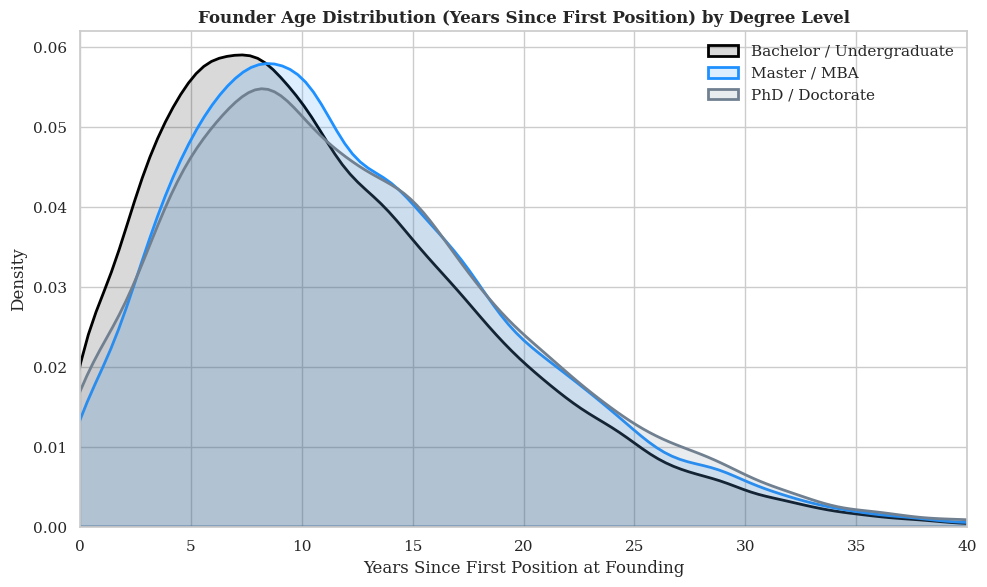

In [9]:
fig_c, ax_c = plt.subplots(figsize=(10, 6))
df_c = df_matched_filtered.copy()
df_c = df_c.dropna(subset=['years_since_first_job'])

sns.kdeplot(data=df_c[df_c['has_bachelor'] == 1.0], x='years_since_first_job', color='black', fill=True, alpha=0.15, linewidth=2, label='Bachelor / Undergraduate', ax=ax_c)
sns.kdeplot(data=df_c[(df_c['has_master'] == 1.0) | (df_c['has_mba'] == 1.0)], x='years_since_first_job', color='dodgerblue', fill=True, alpha=0.15, linewidth=2, label='Master / MBA', ax=ax_c)
sns.kdeplot(data=df_c[df_c['has_phd'] == 1.0], x='years_since_first_job', color='slategrey', fill=True, alpha=0.15, linewidth=2, label='PhD / Doctorate', ax=ax_c)

ax_c.set_title("Founder Age Distribution (Years Since First Position) by Degree Level", fontsize=12, fontweight='bold')
ax_c.set_xlabel("Years Since First Position at Founding")
ax_c.set_ylabel("Density")
ax_c.set_xlim(0, 40)
ax_c.legend(frameon=False)
plt.tight_layout()

fig_c_path = os.path.join(output_fig_dir, "Figure_3c_age_distribution.png")
plt.savefig(fig_c_path, dpi=300, bbox_inches='tight')
plt.show()


## Section D: Professional Position Breakdown for Degree Levels

We cross-tabulate degree level (PhD / Doctorate vs Bachelor / Undergraduate) against the founder's prior role category (Business vs Technical position):
1. **PhD + Technical Role** (dashed slategrey line)
2. **PhD + Business Role** (solid slategrey line)
3. **Bachelor + Technical Role** (dashed black line)
4. **Bachelor + Business Role** (solid black line)


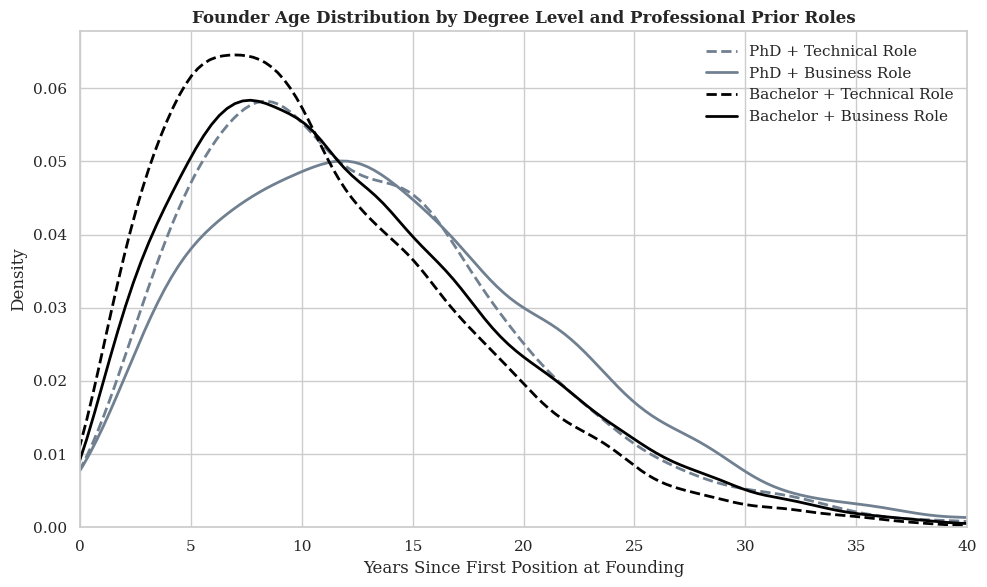

,Subgroup,Count,Mean Experience (Years),Median Experience (Years)
0,PhD + Technical Role,1536,12.55,11.41
1,PhD + Business Role,1544,14.05,13.00
2,Bachelor + Technical Role,10063,10.89,9.51
3,Bachelor + Business Role,16732,12.18,10.88


In [10]:
df_d = df_matched_filtered[df_matched_filtered['prior_role_category'].isin(['Business', 'Technical'])].copy()
df_d = df_d.dropna(subset=['years_since_first_job'])

g1 = df_d[(df_d['has_phd'] == 1.0) & (df_d['prior_role_category'] == 'Technical')]
g2 = df_d[(df_d['has_phd'] == 1.0) & (df_d['prior_role_category'] == 'Business')]
g3 = df_d[(df_d['has_bachelor'] == 1.0) & (df_d['prior_role_category'] == 'Technical')]
g4 = df_d[(df_d['has_bachelor'] == 1.0) & (df_d['prior_role_category'] == 'Business')]

fig_d, ax_d = plt.subplots(figsize=(10, 6))

sns.kdeplot(data=g1, x='years_since_first_job', color='slategrey', linestyle='--', linewidth=2, label='PhD + Technical Role', ax=ax_d)
sns.kdeplot(data=g2, x='years_since_first_job', color='slategrey', linestyle='-', linewidth=2, label='PhD + Business Role', ax=ax_d)
sns.kdeplot(data=g3, x='years_since_first_job', color='black', linestyle='--', linewidth=2, label='Bachelor + Technical Role', ax=ax_d)
sns.kdeplot(data=g4, x='years_since_first_job', color='black', linestyle='-', linewidth=2, label='Bachelor + Business Role', ax=ax_d)

ax_d.set_title("Founder Age Distribution by Degree Level and Professional Prior Roles", fontsize=12, fontweight='bold')
ax_d.set_xlabel("Years Since First Position at Founding")
ax_d.set_ylabel("Density")
ax_d.set_xlim(0, 40)
ax_d.legend(frameon=False)
plt.tight_layout()

fig_d_path = os.path.join(output_fig_dir, "Figure_3d_education_breakdown.png")
plt.savefig(fig_d_path, dpi=300, bbox_inches='tight')
plt.show()

# Display summary table of statistics
summary_data = []
for name, df_grp in [
    ('PhD + Technical Role', g1),
    ('PhD + Business Role', g2),
    ('Bachelor + Technical Role', g3),
    ('Bachelor + Business Role', g4)
]:
    summary_data.append({
        'Subgroup': name,
        'Count': len(df_grp),
        'Mean Experience (Years)': df_grp['years_since_first_job'].mean(),
        'Median Experience (Years)': df_grp['years_since_first_job'].median()
    })

summary_df = pd.DataFrame(summary_data).round(2)
display(summary_df)


## Section E: Analysis of Education and Experience Pairings

We focus on the subsample of founders who held either a Business or Technical prior role. We count the number of founders in each of the four pairings between education and experience categories:


/var/folders/jf/tf8mlb2j2p96g_4jx_s6pzvm0000gn/T/ipykernel_98808/3503195752.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pairings, x='Pairing', y='Count', palette=colors, ax=ax_e)


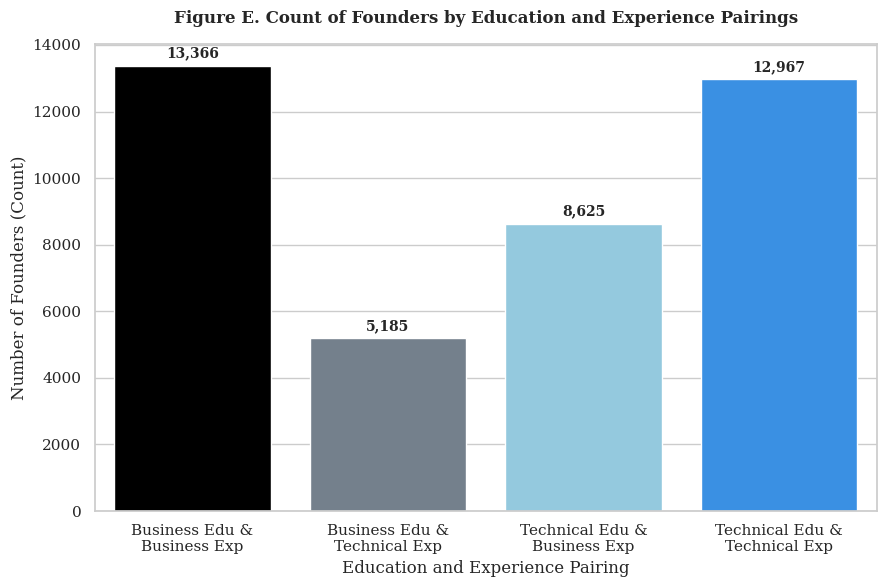

,Pairing,Count
0,Business Edu &\nBusiness Exp,13366
1,Business Edu &\nTechnical Exp,5185
2,Technical Edu &\nBusiness Exp,8625
3,Technical Edu &\nTechnical Exp,12967


In [11]:
df_e = df_matched_filtered[df_matched_filtered['prior_role_category'].isin(['Business', 'Technical'])].copy()
df_e['is_business_edu'] = (df_e['has_business'] == 1.0) | (df_e['has_mba'] == 1.0) | (df_e['has_econ'] == 1.0)
df_e['is_tech_edu'] = (df_e['has_stem'] == 1.0) | (df_e['has_cs'] == 1.0)
df_e['has_business_exp'] = df_e['exp_role_Business'] > 0
df_e['has_tech_exp'] = df_e['exp_role_Technical'] > 0

pairings = {
    'Business Edu &\nBusiness Exp': len(df_e[df_e['is_business_edu'] & df_e['has_business_exp']]),
    'Business Edu &\nTechnical Exp': len(df_e[df_e['is_business_edu'] & df_e['has_tech_exp']]),
    'Technical Edu &\nBusiness Exp': len(df_e[df_e['is_tech_edu'] & df_e['has_business_exp']]),
    'Technical Edu &\nTechnical Exp': len(df_e[df_e['is_tech_edu'] & df_e['has_tech_exp']])
}

df_pairings = pd.DataFrame(list(pairings.items()), columns=['Pairing', 'Count'])

fig_e, ax_e = plt.subplots(figsize=(9, 6))
colors = ['black', 'slategrey', 'skyblue', 'dodgerblue']
sns.barplot(data=df_pairings, x='Pairing', y='Count', palette=colors, ax=ax_e)
ax_e.set_title("Figure E. Count of Founders by Education and Experience Pairings", fontsize=12, fontweight='bold', pad=15)
ax_e.set_ylabel("Number of Founders (Count)")
ax_e.set_xlabel("Education and Experience Pairing")

for p in ax_e.patches:
    height = p.get_height()
    ax_e.annotate(f"{int(height):,}",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_e_path = os.path.join(output_fig_dir, "Figure_3e_pairings.png")
plt.savefig(fig_e_path, dpi=300, bbox_inches='tight')
plt.show()

display(df_pairings)
